In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
from IPython.display import display, Markdown
warnings.filterwarnings('ignore')

# Set style
sns.set(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [12]:
CODE_MAPPING = {
    "AUT": "Austria", "CHE": "Switzerland", "DEU": "Germany", "DNK": "Denmark", 
    "ESP": "Spain", "EST": "Estonia", "FIN": "Finland", "FRA": "France", 
    "GBR": "United Kingdom", "GRC": "Greece", "HUN": "Hungary", "IRL": "Ireland", 
    "ISL": "Iceland", "ITA": "Italy", "LTU": "Lithuania", "LUX": "Luxembourg", 
    "LVA": "Latvia", "NLD": "Netherlands", "NOR": "Norway", "POL": "Poland", 
    "PRT": "Portugal", "SVK": "Slovakia", "SVN": "Slovenia", "SWE": "Sweden"
}

def load_data(filepath):
    df = pd.read_csv(filepath)
    df['Year'] = pd.to_numeric(df['Year'])
    df = df.sort_values(['REF_AREA', 'Year'])
    
    # Handle missing values
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df.groupby('REF_AREA')[numeric_cols].transform(lambda x: x.fillna(x.mean()))
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
    
    # Feature Engineering
    df['birth_rate_lag1'] = df.groupby('REF_AREA')['birth_rate'].shift(1)
    df['birth_rate_lag2'] = df.groupby('REF_AREA')['birth_rate'].shift(2)
    df = df.dropna(subset=['birth_rate_lag1', 'birth_rate_lag2'])
    
    return df

df = load_data("D:/DAP_project/master_data.csv")
print(f"Data loaded. Shape: {df.shape}")

Data loaded. Shape: (480, 26)


In [13]:
def generate_summary():
    summary_data = []
    countries = df['REF_AREA'].unique()
    features = ['Year', 'fertility', 'emp_rate', 'gov_spending', 'birth_rate_lag1', 'birth_rate_lag2']
    target = 'birth_rate'

    for code in countries:
        country_data = df[df['REF_AREA'] == code]
        
        # Validation for Accuracy Metrics (Last 3 years)
        train_idx, val_idx = country_data.index[:-3], country_data.index[-3:]
        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(country_data.loc[train_idx, features], country_data.loc[train_idx, target])
        
        actuals = country_data.loc[val_idx, target]
        preds = model.predict(country_data.loc[val_idx, features])
        
        mae = mean_absolute_error(actuals, preds)
        # Calculate Accuracy as 100 - MAPE
        mape = np.mean(np.abs((actuals - preds) / actuals)) * 100
        accuracy = 100 - mape
        
        # Final Forecast up to 2028
        model.fit(country_data[features], country_data[target])
        last_row = country_data.iloc[-1]
        lag1, lag2 = last_row['birth_rate'], last_row['birth_rate_lag1']
        curr_f, curr_e, curr_g = last_row['fertility'], last_row['emp_rate'], last_row['gov_spending']
        f_t, e_t, g_t = country_data['fertility'].diff().mean() or 0, country_data['emp_rate'].diff().mean() or 0, country_data['gov_spending'].diff().mean() or 0
        
        final_pred = 0
        for y in range(2022, 2029):
            curr_f += f_t; curr_e += e_t; curr_g += g_t
            X_new = pd.DataFrame([[y, curr_f, curr_e, curr_g, lag1, lag2]], columns=features)
            final_pred = model.predict(X_new)[0]
            lag2, lag1 = lag1, final_pred
        
        rate_2021 = last_row['birth_rate']
        diff = final_pred - rate_2021
        pct_change = (diff / rate_2021) * 100
        
        insight = "Stable"
        if diff < -0.5: insight = "Significant Decline"
        elif diff < -0.1: insight = "Slight Decrease"
        elif diff > 0.5: insight = "Substantial Growth"
        elif diff > 0.1: insight = "Steady Upward"

        summary_data.append({
            "Country": CODE_MAPPING.get(code, code),
            "Rate 2021": round(rate_2021, 2),
            "Forecast 2028": round(final_pred, 2),
            "Change (%)": f"{pct_change:+.1f}%",
            "Accuracy": f"{accuracy:.1f}%",
            "MAE": round(mae, 4),
            "AI Insight": insight
        })
    
    return pd.DataFrame(summary_data)

summary_df = generate_summary()
display(Markdown("### 📊 Forecast Results (to 2028) & Model Accuracy Summary"))
summary_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

### 📊 Forecast Results (to 2028) & Model Accuracy Summary

,Country,Rate 2021,Forecast 2028,Change (%),Accuracy,MAE,AI Insight
0,Hungary,9.74,9.69,-0.5%,99.7%,0.0336,Stable
1,Germany,9.57,9.48,-0.8%,98.8%,0.1164,Stable
2,Denmark,10.87,10.58,-2.6%,98.5%,0.1649,Slight Decrease
3,Austria,9.64,9.92,+3.0%,98.4%,0.1559,Steady Upward
4,Switzerland,10.34,10.53,+1.8%,98.3%,0.1685,Steady Upward
5,Luxembourg,10.54,10.36,-1.7%,98.0%,0.2072,Slight Decrease
6,Netherlands,10.27,9.78,-4.8%,97.6%,0.2372,Slight Decrease
7,Iceland,13.23,12.82,-3.1%,97.5%,0.3278,Slight Decrease
8,Slovakia,10.36,10.37,+0.1%,97.1%,0.3043,Stable
9,Sweden,11.01,11.08,+0.7%,96.8%,0.3520,Stable


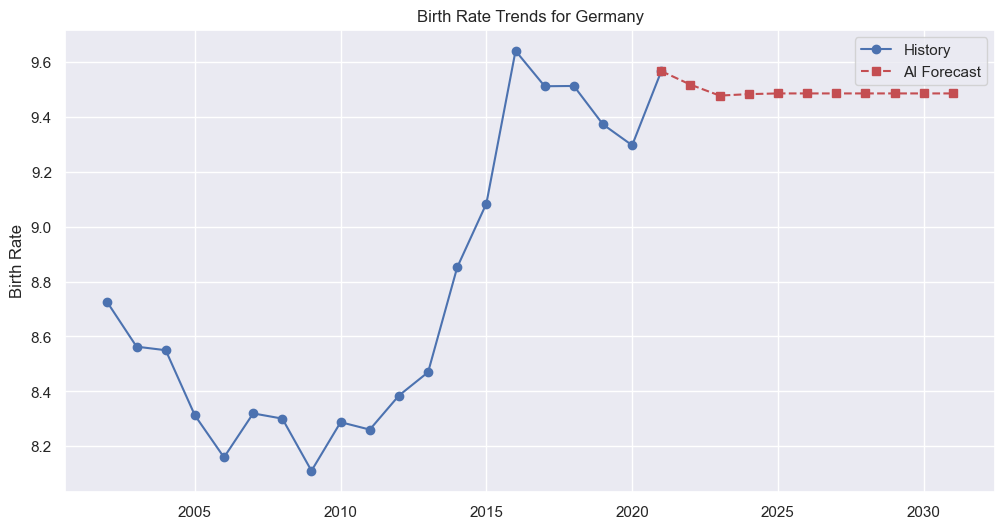

In [14]:
def plot_country(country_name):
    code = next((k for k, v in CODE_MAPPING.items() if v == country_name), country_name)
    country_data = df[df['REF_AREA'] == code]
    features = ['Year', 'fertility', 'emp_rate', 'gov_spending', 'birth_rate_lag1', 'birth_rate_lag2']
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(country_data[features], country_data['birth_rate'])
    
    f_years, f_vals = [], []
    last_row = country_data.iloc[-1]
    l1, l2 = last_row['birth_rate'], last_row['birth_rate_lag1']
    cf, ce, cg = last_row['fertility'], last_row['emp_rate'], last_row['gov_spending']
    ft, et, gt = country_data['fertility'].diff().mean() or 0, country_data['emp_rate'].diff().mean() or 0, country_data['gov_spending'].diff().mean() or 0

    for y in range(2022, 2032):
        cf += ft; ce += et; cg += gt
        pred = model.predict(pd.DataFrame([[y, cf, ce, cg, l1, l2]], columns=features))[0]
        f_years.append(y); f_vals.append(pred)
        l2, l1 = l1, pred

    plt.plot(country_data['Year'], country_data['birth_rate'], marker='o', label='History')
    plt.plot([country_data['Year'].iloc[-1]] + f_years, [country_data['birth_rate'].iloc[-1]] + f_vals, 
             '--rs', label='AI Forecast')
    plt.title(f"Birth Rate Trends for {country_name}")
    plt.ylabel("Birth Rate")
    plt.legend()
    plt.show()

plot_country('Germany')